# Compute Raw PTR Values
April 2, 2024

Recompute the raw PTR values from the input G data. Update to use the 0.01 pseudocounts.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
    

In [157]:
from src.raw_ptr_analysis import RawPTRAnalysis

rep2_chrom_dir = 'output/archive/deconvolve_rep2_g006_2024_02_22/chromatin/'
raw_ptr_analysis_2 = RawPTRAnalysis(rep2_chrom_dir, replicate=2)
raw_ptr_analysis_2.load_g_files()

G shapes:  15 16 50
1/4739 - 00:00:00.007
2001/4739 - 00:00:03.759
4001/4739 - 00:00:07.146


In [163]:
raw_ptr_analysis_2.compute_raw_ptr_values()

Computing raw PTR values
Done. - 00:03:17.233


In [180]:
from src.peak_to_trough_anaysis import PeakToTroughAnalysis

ptr_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin_ptr_fix_eps_1/'
peak_to_trough_analysis_eps1 = PeakToTroughAnalysis(ptr_dir)
peak_to_trough_analysis_eps1.compute_summary_metrics()


In [181]:
combined_deconvolved_raw_rep2_comparison = peak_to_trough_analysis_eps1.metrics_df[['gene', 
    'mean_ptr']].join(raw_ptr_analysis_2.mean_g_ptrs_df, lsuffix='_deconvolved', 
                     rsuffix='_raw')
combined_deconvolved_raw_rep2_comparison.head(2)

,gene,mean_ptr_deconvolved,mean_ptr_raw
orf_name,,,
YAL067W-A,YAL067W-A,1.169257,NaN
YAL067C,SEO1,1.404367,1.461957


Text(0, 0.5, 'Deconvolved PTR, combined model')

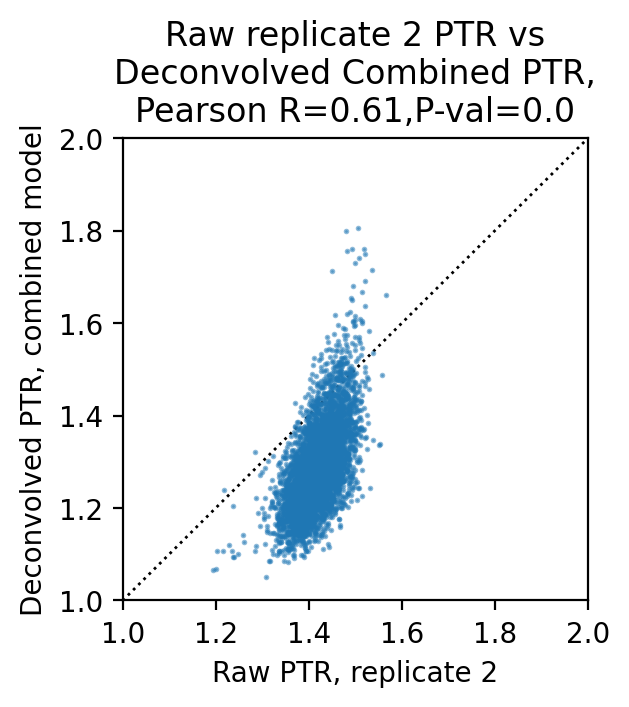

In [200]:
from scipy.stats import pearsonr

plt.figure(figsize=(3, 3))
plt_dat = combined_deconvolved_raw_rep2_comparison.dropna()
x, y = plt_dat.mean_ptr_raw, \
    plt_dat.mean_ptr_deconvolved

pearsonr, pval = pearsonr(x, y)

plt.title(f"Raw replicate 2 PTR vs\nDeconvolved Combined PTR,\n"
          f"Pearson R={pearsonr:.2f}, P-val={pval}")
plt.scatter(x, y, s=1, alpha=0.5)
plt.plot([1, 2], [1, 2], c='black', lw=1, zorder=0, ls='dotted')
plt.xlim(1, 2)
plt.ylim(1, 2)
plt.xlabel("Raw PTR, replicate 2")
plt.ylabel("Deconvolved PTR, combined model")
